In [2]:
%reload_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized
from hcg.interpolant import Interpolant as Interpolant
from hcg.interpolant import FlowMatcher as FlowMatcher
from hcg.interpolant import plot_path_trajectories as plot_path_trajectories
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

experiment_id = "DivergingCheckerEval"  # Use a fixed ID for reproducibility
if not os.path.exists(experiment_id):
    os.makedirs(experiment_id)

model_path = "PretrainedToyModels"


device → cuda


In [15]:
def train_all_three_models(interpolant, name):
    u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device) # X | A
    s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device) # X | A
    fm_trainer_custom = FlowMatcher(u_model1, s_model1, interpolant=interpolant)
    fm_trainer_custom.train(sample_data_model1, n_iters=2000, plot_cond_val=1.0) # Using few iterations for demo
    torch.save(u_model1.state_dict(), f"{experiment_id}/u_model1_X_given_A_alpha={name}.pth")
    torch.save(s_model1.state_dict(), f"{experiment_id}/s_model1_X_given_A_alpha={name}.pth")

    u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device) # X, Y | B
    s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device) # X, Y | B
    fm_trainer_default = FlowMatcher(u_model2, s_model2, interpolant=interpolant)
    fm_trainer_default.train(sample_data_model2, n_iters=10000, plot_cond_val=1.0) # Using few iterations for demo
    torch.save(u_model2.state_dict(), f"{experiment_id}/u_model2_XY_given_B_alpha={name}.pth")
    torch.save(s_model2.state_dict(), f"{experiment_id}/s_model2_XY_given_B_alpha={name}.pth")

    u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X
    s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X
    fm_trainer_default = FlowMatcher(u_model3, s_model3, interpolant=interpolant)
    fm_trainer_default.train(sample_data_model3, n_iters=2000) # Using few iterations for demo
    torch.save(u_model3.state_dict(), f"{experiment_id}/u_model3_X_alpha={name}.pth")
    torch.save(s_model3.state_dict(), f"{experiment_id}/s_model3_X_alpha={name}.pth")


def load_interpolants_from_json(path):
    """Load interpolants.json and return a dict of Interpolant objects."""
    with open(path, "r") as f:
        interpolants_raw = json.load(f)

    interpolants = {}
    for name, funcs in interpolants_raw.items():
        alpha_t = eval(funcs["alpha_t"], {"torch": torch})
        beta_t = eval(funcs["beta_t"], {"torch": torch})
        d_alpha_t = eval(funcs["d_alpha_t"], {"torch": torch})
        d_beta_t = eval(funcs["d_beta_t"], {"torch": torch})
        interpolants[name] = Interpolant(alpha_t, beta_t, d_alpha_t, d_beta_t, name=name)
    return interpolants
interpolant_schedules = load_interpolants_from_json("interpolant_schedules.json")

if False:    # use the python script to run in the background
    for name in interpolant_schedules.keys():
        train_all_three_models(interpolant=interpolant_schedules[name], name=name)


# Constant Gammas [1,-1,1]

In [ ]:
bs = 5000

for name in list(interpolant_schedules.keys()):
    if not os.path.exists(f"{model_path}/u_model1_X_given_A_alpha={name}.pth"):
        print(f"Pass {name}. Pretrained Models does not exist.")
        continue

    print(name)
    u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={name}.pth")); u_model1.eval()
    s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={name}.pth")); s_model1.eval()
    u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={name}.pth")); u_model2.eval()
    s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={name}.pth")); s_model2.eval()
    u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={name}.pth")); u_model3.eval()
    s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={name}.pth")); s_model3.eval()

    # def score_from_velocity(v_fn, x, t, C=None):
    #     alpha_t = interpolant_schedules[name].alpha_t
    #     beta_t = interpolant_schedules[name].beta_t
    #     d_alpha_t = interpolant_schedules[name].d_alpha_t
    #     d_beta_t = interpolant_schedules[name].d_beta_t
    #     v_val = v_fn(x, t, C) if C is not None else v_fn(x,t)
    #     eps = 1e-3
    #     dbeta_over_beta = (d_beta_t(t) / beta_t(t))
    #     numerator_terms = v_val - dbeta_over_beta * x
    #     denominator_terms = alpha_t(t) * ((dbeta_over_beta) * alpha_t(t) - d_alpha_t(t)) + eps
    #     return numerator_terms / denominator_terms

    # def v1_fn(x, t, A): return u_model1(x, t, A)
    # def s1_fn(x, t, A): return score_from_velocity(v1_fn, x, t, A)
    # def v2_fn(x, t): return u_model3(x, t)
    # def s2_fn(x, t): return score_from_velocity(v2_fn, x, t)
    # def v3_fn(z, t, B): return u_model2(z, t, B)
    # def s3_fn(z, t, B): return score_from_velocity(v3_fn, z, t, B)
    # def sigma_fn(t): return 0.5 * torch.ones_like(t)
    # print("Models loaded.")

    def v1_fn(x, t, A): return u_model1(x, t, A)
    def s1_fn(x, t, A): return s_model1(x, t, A)
    def v2_fn(x, t): return u_model3(x, t)
    def s2_fn(x, t): return s_model3(x, t)
    def v3_fn(z, t, B): return u_model2(z, t, B)
    def s3_fn(z, t, B): return s_model2(z, t, B)
    def sigma_fn(t): return 0.5 * torch.ones_like(t)
    print("Models loaded.")


    gamma_1 = lambda t: torch.ones_like(t)
    gamma_2 = lambda t: torch.ones_like(t) * torch.tensor(-1.0)
    gamma_3 = lambda t: torch.ones_like(t)

    # use torch.autograd to compute derivatives
    d_gamma_1 = lambda t: torch.zeros_like(t)
    d_gamma_2 = lambda t: torch.zeros_like(t)
    d_gamma_3 = lambda t: torch.zeros_like(t)


    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values

    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, 
        v_fn_list=[
            lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
            lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
            lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
        ],
        s_fn_list=[
            lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
            lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
            lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
        ],
        gamma_list=[gamma_1, gamma_2, gamma_3],
        d_gamma_list=[d_gamma_1, d_gamma_2, d_gamma_3],
        proj_list=[
            lambda z: z[:, :1],    # project to X 
            lambda z: z[:, :1],    # project to X
            lambda z: z            # identity for Z
        ],
        emb_list=[
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda z: z  # identity
        ],
        sigma_fn=sigma_fn,
        # v_star = lambda z, t: v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + 
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=100,
        device="cuda",
        resample=True,
        ess_threshold=0.8,
        print_resample_history=True
    )
    samples = samples.cpu().numpy()
    plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={name},{name},{name}_gamma=1,-1,1")
    plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={name},{name},{name}_gamma=1,-1,1", deg=-50)

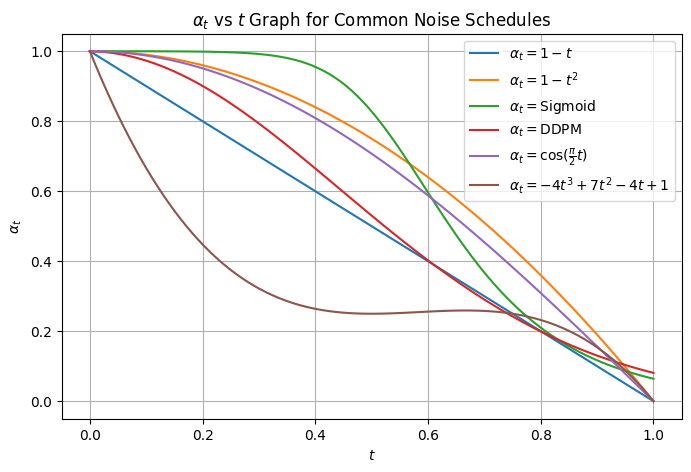

In [20]:
t = torch.linspace(0.0, 1.0, 100)

name_eq = {
    "custom_poly": r"$\alpha_t = -4t^3+7t^2-4t+1$",
    "ddpm_linear": r"$\alpha_t = \text{DDPM}$",
    "1-t**2": r"$\alpha_t = 1-t^2$",
    "sigmoid": r"$\alpha_t = \text{Sigmoid}$",
    "default_linear": r"$\alpha_t = 1-t$",
    "cos_t": r"$\alpha_t=\cos(\frac{\pi}{2}t)$"
}


plt.figure(figsize=(8, 5)) 
for name in interpolant_schedules.keys():
    plt.plot(t.numpy(), interpolant_schedules[name].alpha_t(t).numpy(), label=name_eq[name])
    # print(name, interpolant_schedules[name].alpha_t(0), interpolant_schedules[name].beta_t(0), interpolant_schedules[name].d_alpha_t(0), interpolant_schedules[name].d_beta_t(0))
plt.xlabel(r'$t$')
plt.ylabel(r'$\alpha_t$')
plt.title(r'$\alpha_t$ vs $t$ Graph for Common Noise Schedules')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "alpha_t_plot.png"))
plt.show()

# Suppose we want to combine models with heterogeneous schedules
$$
\frac{q^{(1)}_t(X_t \mid A)q^{(3)}_t(X_t, Y_t \mid B)}{q^{(2)}_t(X_t)}
$$
each with schedules 
$$
(\alpha^{(1)}_t,\alpha^{(2)}_t,\alpha^{(3)}_t)
$$

Criterion(0.99999) = 17452441600.0


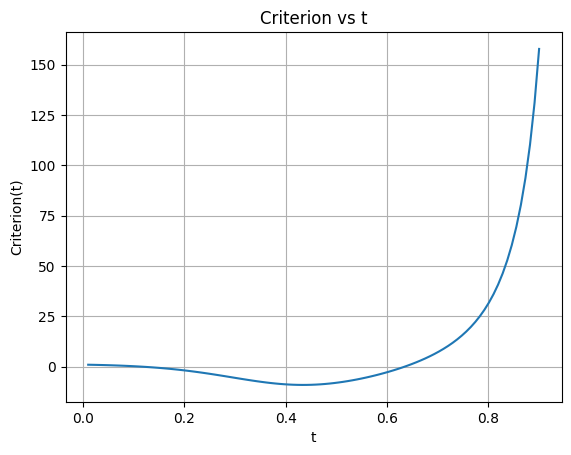

Criterion = 0 at t = 0.10888887941837311
Criterion = 0 at t = 0.6303030252456665


In [98]:
names = ["default_linear", "custom_poly", "default_linear"]
# names = ["ddpm_linear", "default_linear", "default_linear"]


gamma_1 = lambda t : torch.tensor(1)
gamma_2 = lambda t : torch.tensor(1) * torch.tensor(-1)
gamma_3 = lambda t : torch.tensor(1) #+ 14 * torch.tensor(t * (1-t))

d_gamma_1 = lambda t: torch.zeros_like(t)
d_gamma_2 = lambda t: torch.zeros_like(t)
d_gamma_3 = lambda t: torch.zeros_like(t)

gamma_list = [gamma_1, gamma_2, gamma_3]

Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "Criterion_plot.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

Models loaded.
Simulating with problematic gammas


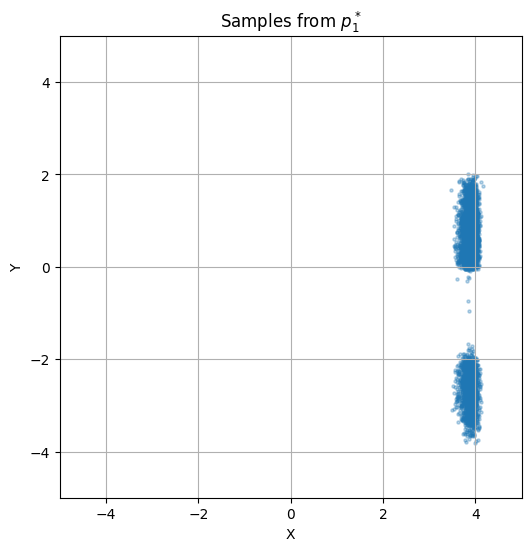

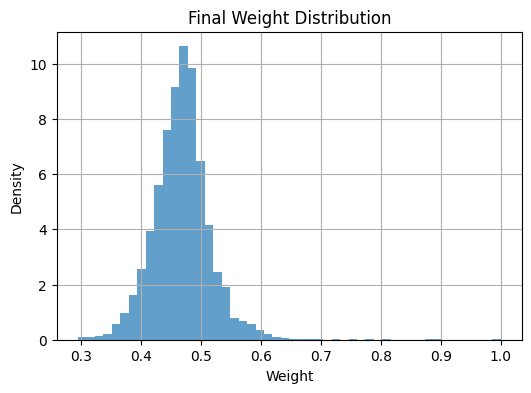

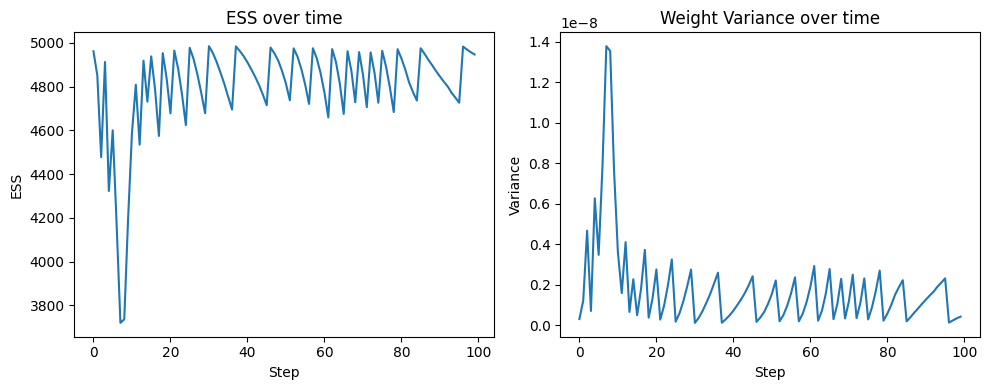

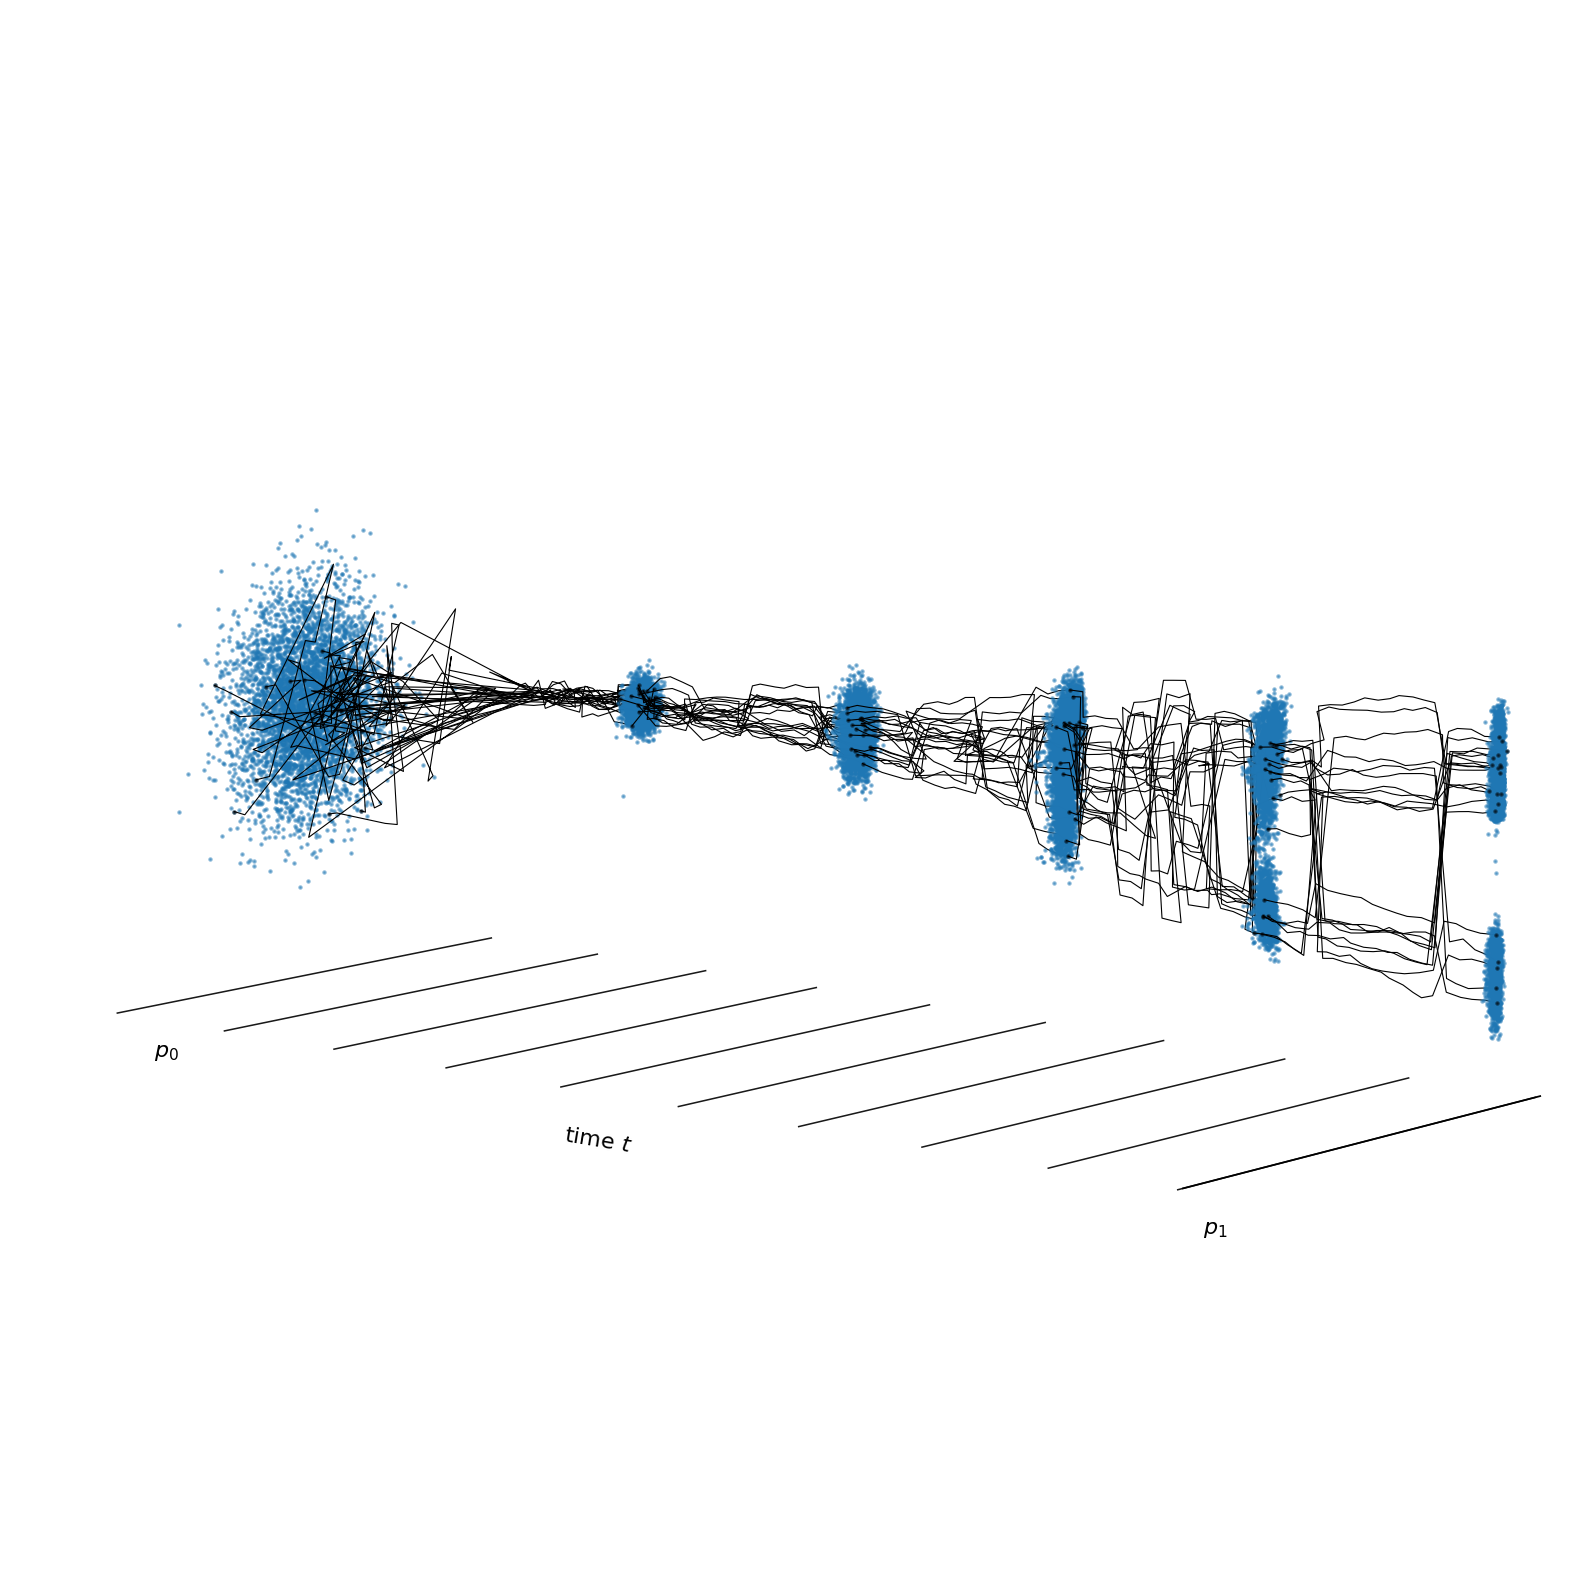

In [99]:
bs = 5000

u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")

print("Simulating with problematic gammas")
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[gamma_1, gamma_2, gamma_3],
    d_gamma_list=[d_gamma_1, d_gamma_2, d_gamma_3],
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    # v_star = lambda z, t: v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + 
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.95,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_gamma={gamma_list}")
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_gamma={gamma_list}", deg=-50)

Criterion(0.99999) = 17452539904.0


/tmp/ipykernel_883457/3958520961.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_2 = lambda t : torch.tensor(1) * torch.tensor(-1) * torch.tensor((1-2*t)**2)


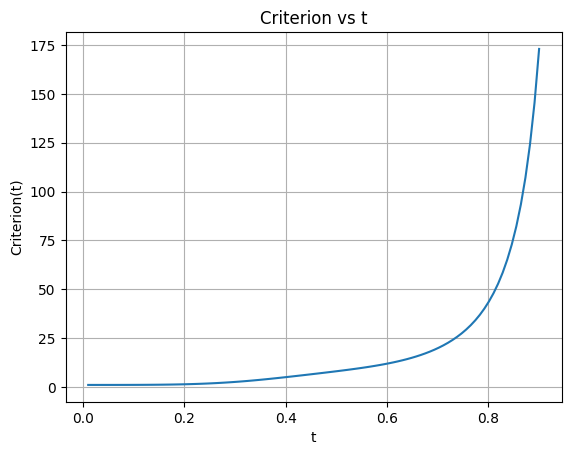

In [100]:
names = ["default_linear", "custom_poly", "default_linear"]
# names = ["ddpm_linear", "default_linear", "default_linear"]

alpha_1 = lambda t : interpolant_schedules[names[0]].alpha_t(t)
alpha_2 = lambda t : interpolant_schedules[names[1]].alpha_t(t) #torch.tensor((1-t) * (t + (1-2*t)**2))
alpha_3 = lambda t : interpolant_schedules[names[2]].alpha_t(t)

gamma_1 = lambda t : torch.tensor(1)
gamma_2 = lambda t : torch.tensor(1) * torch.tensor(-1) * torch.tensor((1-2*t)**2)
gamma_3 = lambda t : torch.tensor(1)

d_gamma_1 = lambda t: torch.zeros_like(t)
d_gamma_2 = lambda t: torch.zeros_like(t) + torch.tensor(-8*t + 4)
d_gamma_3 = lambda t: torch.zeros_like(t)

gamma_list = [gamma_1, gamma_2, gamma_3]
alpha_list = [alpha_1, alpha_2, alpha_3]

Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "Criterion_plot.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

Models loaded.
Simulating with adaptive gammas


/tmp/ipykernel_883457/3958520961.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_2 = lambda t : torch.tensor(1) * torch.tensor(-1) * torch.tensor((1-2*t)**2)
/tmp/ipykernel_883457/3958520961.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d_gamma_2 = lambda t: torch.zeros_like(t) + torch.tensor(-8*t + 4)


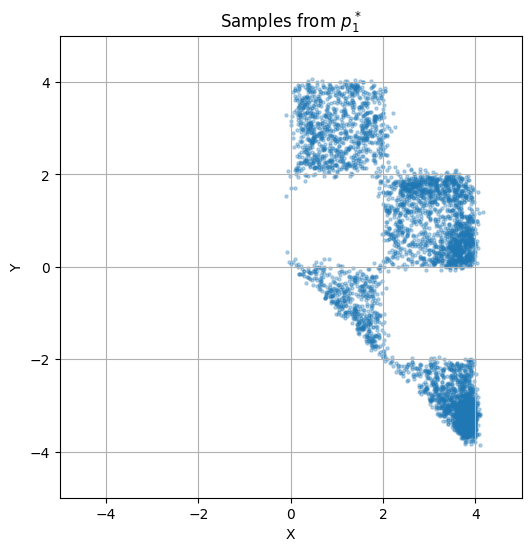

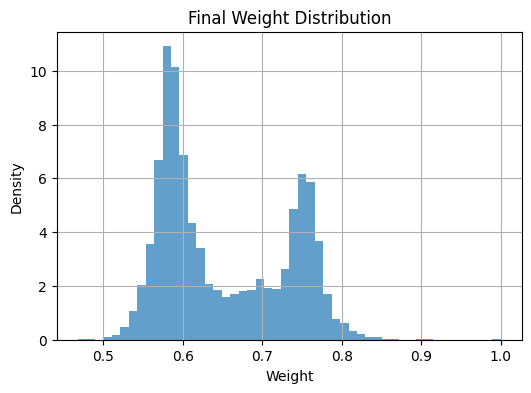

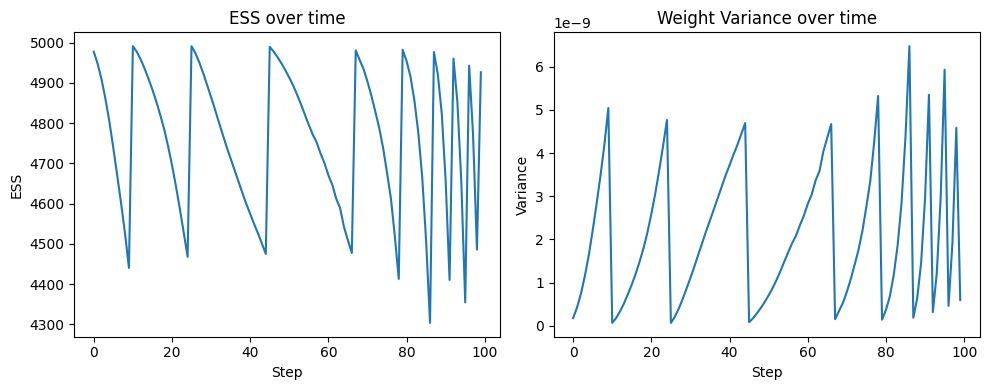

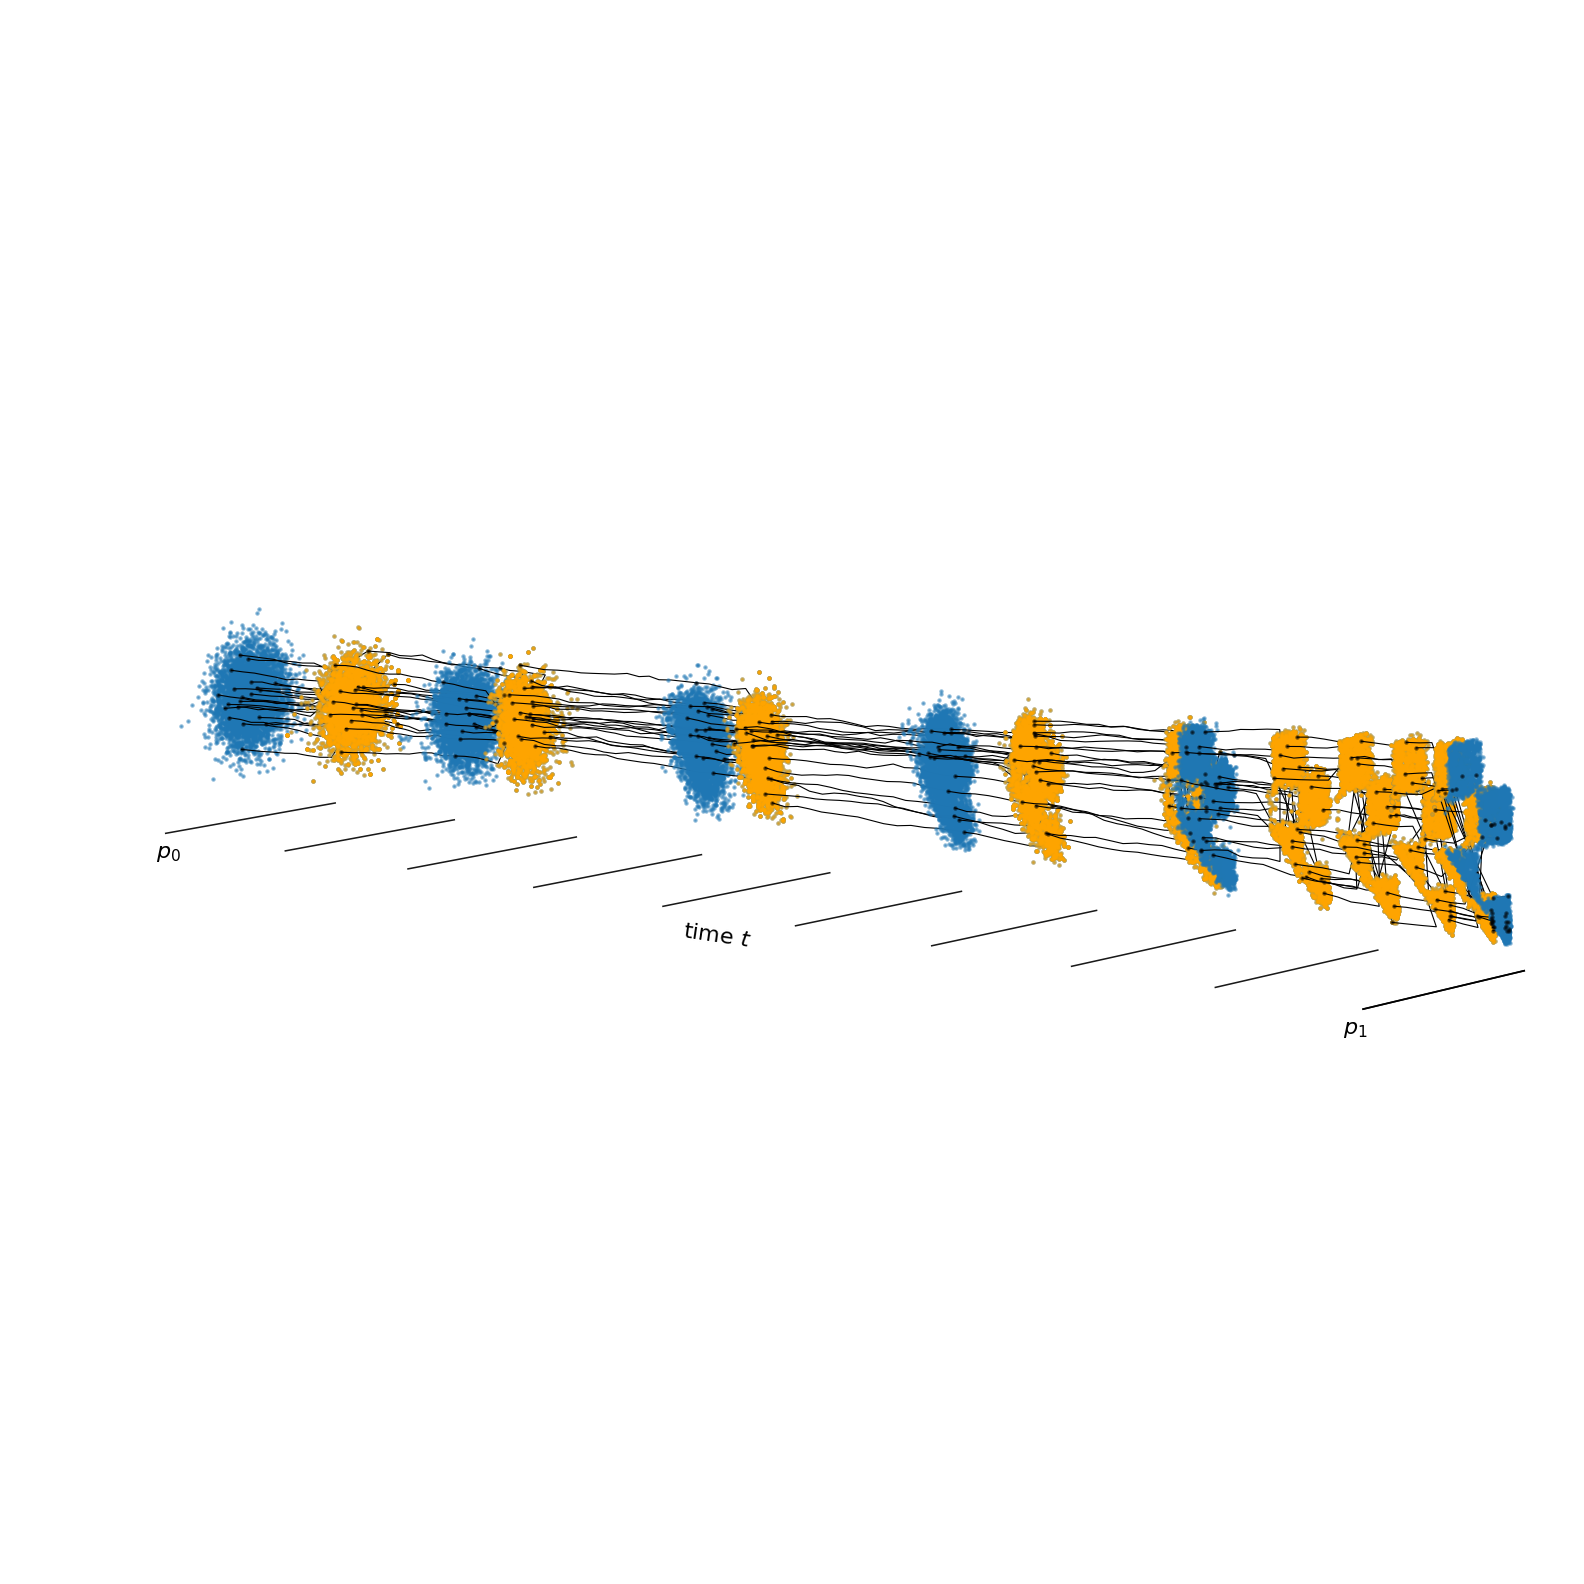

In [102]:
bs = 5000

u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")

print("Simulating with adaptive gammas")
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[gamma_1, gamma_2, gamma_3],
    d_gamma_list=[d_gamma_1, d_gamma_2, d_gamma_3],
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    # v_star = lambda z, t: v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + 
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.9,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_gamma={gamma_list}")
plot_path_trajectories(sample_history, n_frame=6, resample_history=resample_history, experiment_id=experiment_id, name=f"alpha={names}_gamma={gamma_list}", deg=-50)

# Different Scheduling for $\alpha_t$, same constant $\gamma_i$'s

Models loaded.


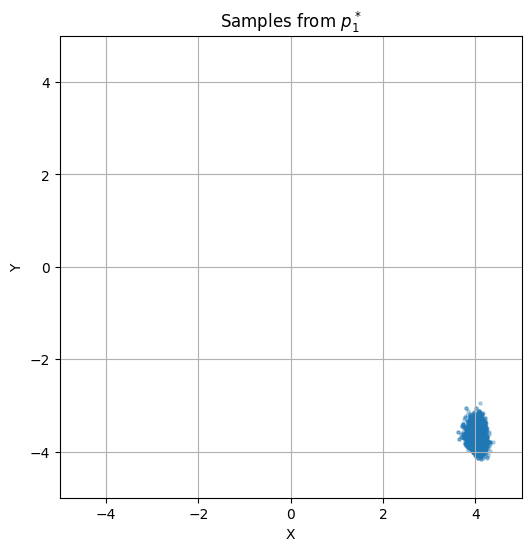

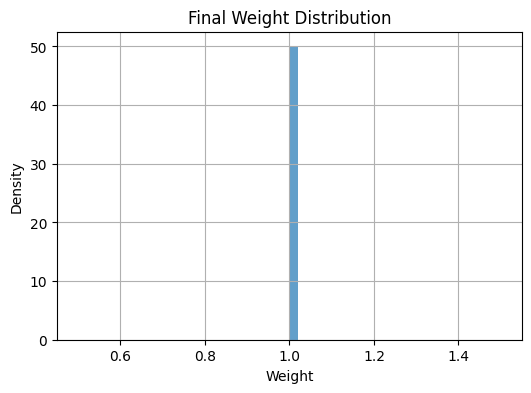

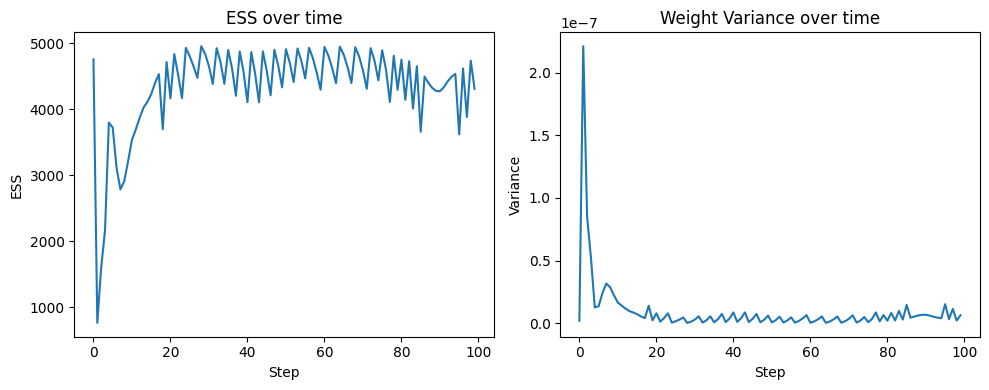

In [87]:
bs = 5000
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"DivergingChecker/u_model1_X_given_A_default_alpha.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"DivergingChecker/s_model1_X_given_A_default_alpha.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"DivergingChecker/u_model2_XY_given_B_default_alpha.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"DivergingChecker/s_model2_XY_given_B_default_alpha.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"DivergingChecker/u_model3_X_different_alpha_t.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"DivergingChecker/s_model3_X_different_alpha_t.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    # v_star = lambda z, t: torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.9,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/different_alpha_constant_gammas")

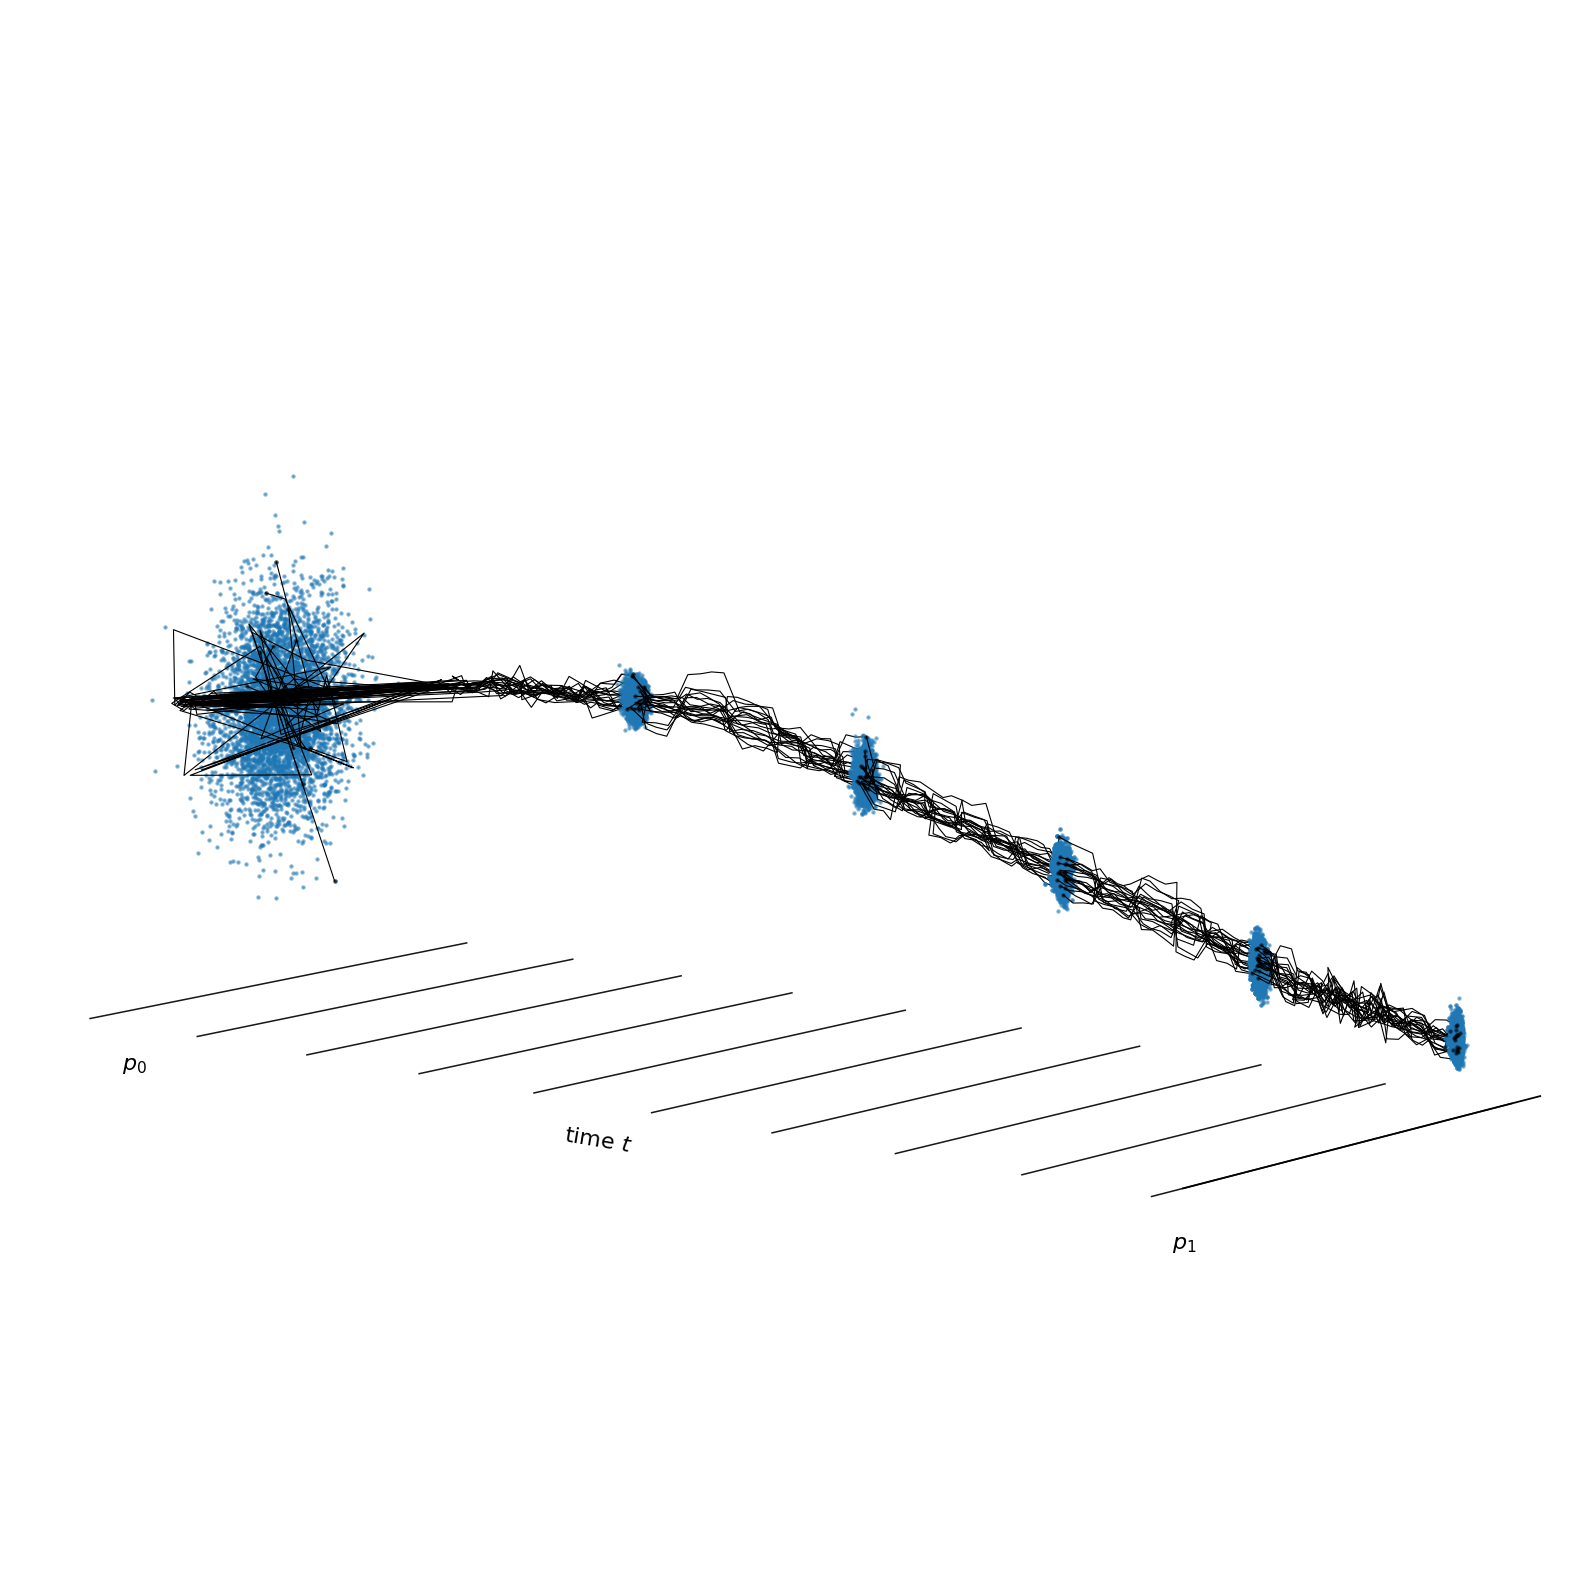

In [88]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name="different_alphas_constant_gammas", deg=-50)

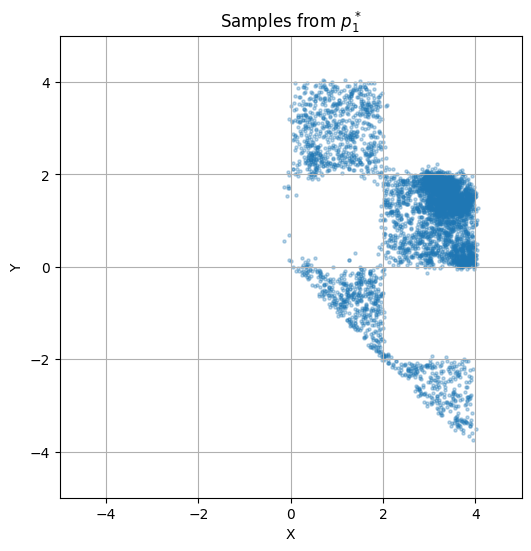

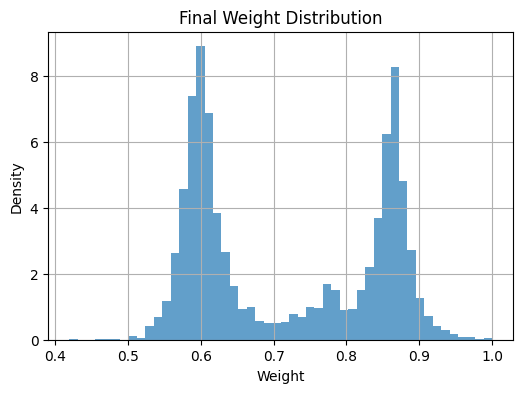

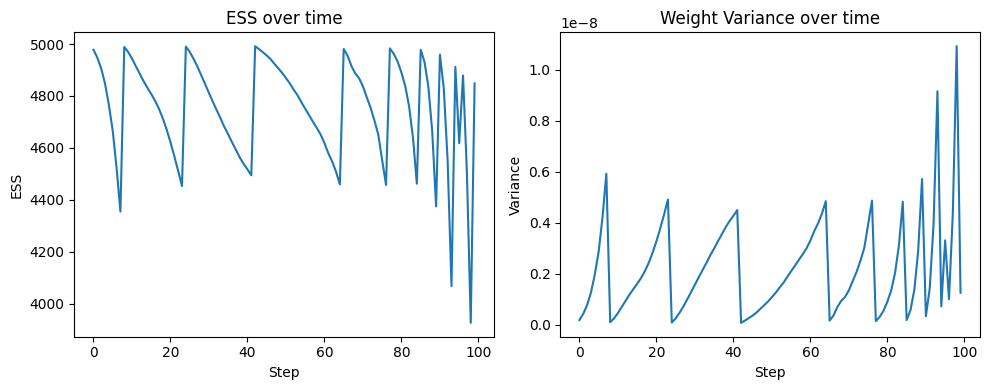

In [97]:
gamma_1 = lambda t: torch.ones_like(t)
gamma_2 = lambda t: -1 * (1 - 2 * t)**2
gamma_3 = lambda t: torch.ones_like(t)
d_gamma_1 = lambda t: torch.zeros_like(t)
d_gamma_2 = lambda t: 4 * (1 - 2 * t)
d_gamma_3 = lambda t: torch.zeros_like(t)



x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[gamma_1, gamma_2, gamma_3],
    d_gamma_list=[d_gamma_1, d_gamma_2, d_gamma_3],
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star = lambda z, t: v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + 
    # v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.9,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/different_alphas_adaptive_gammas")

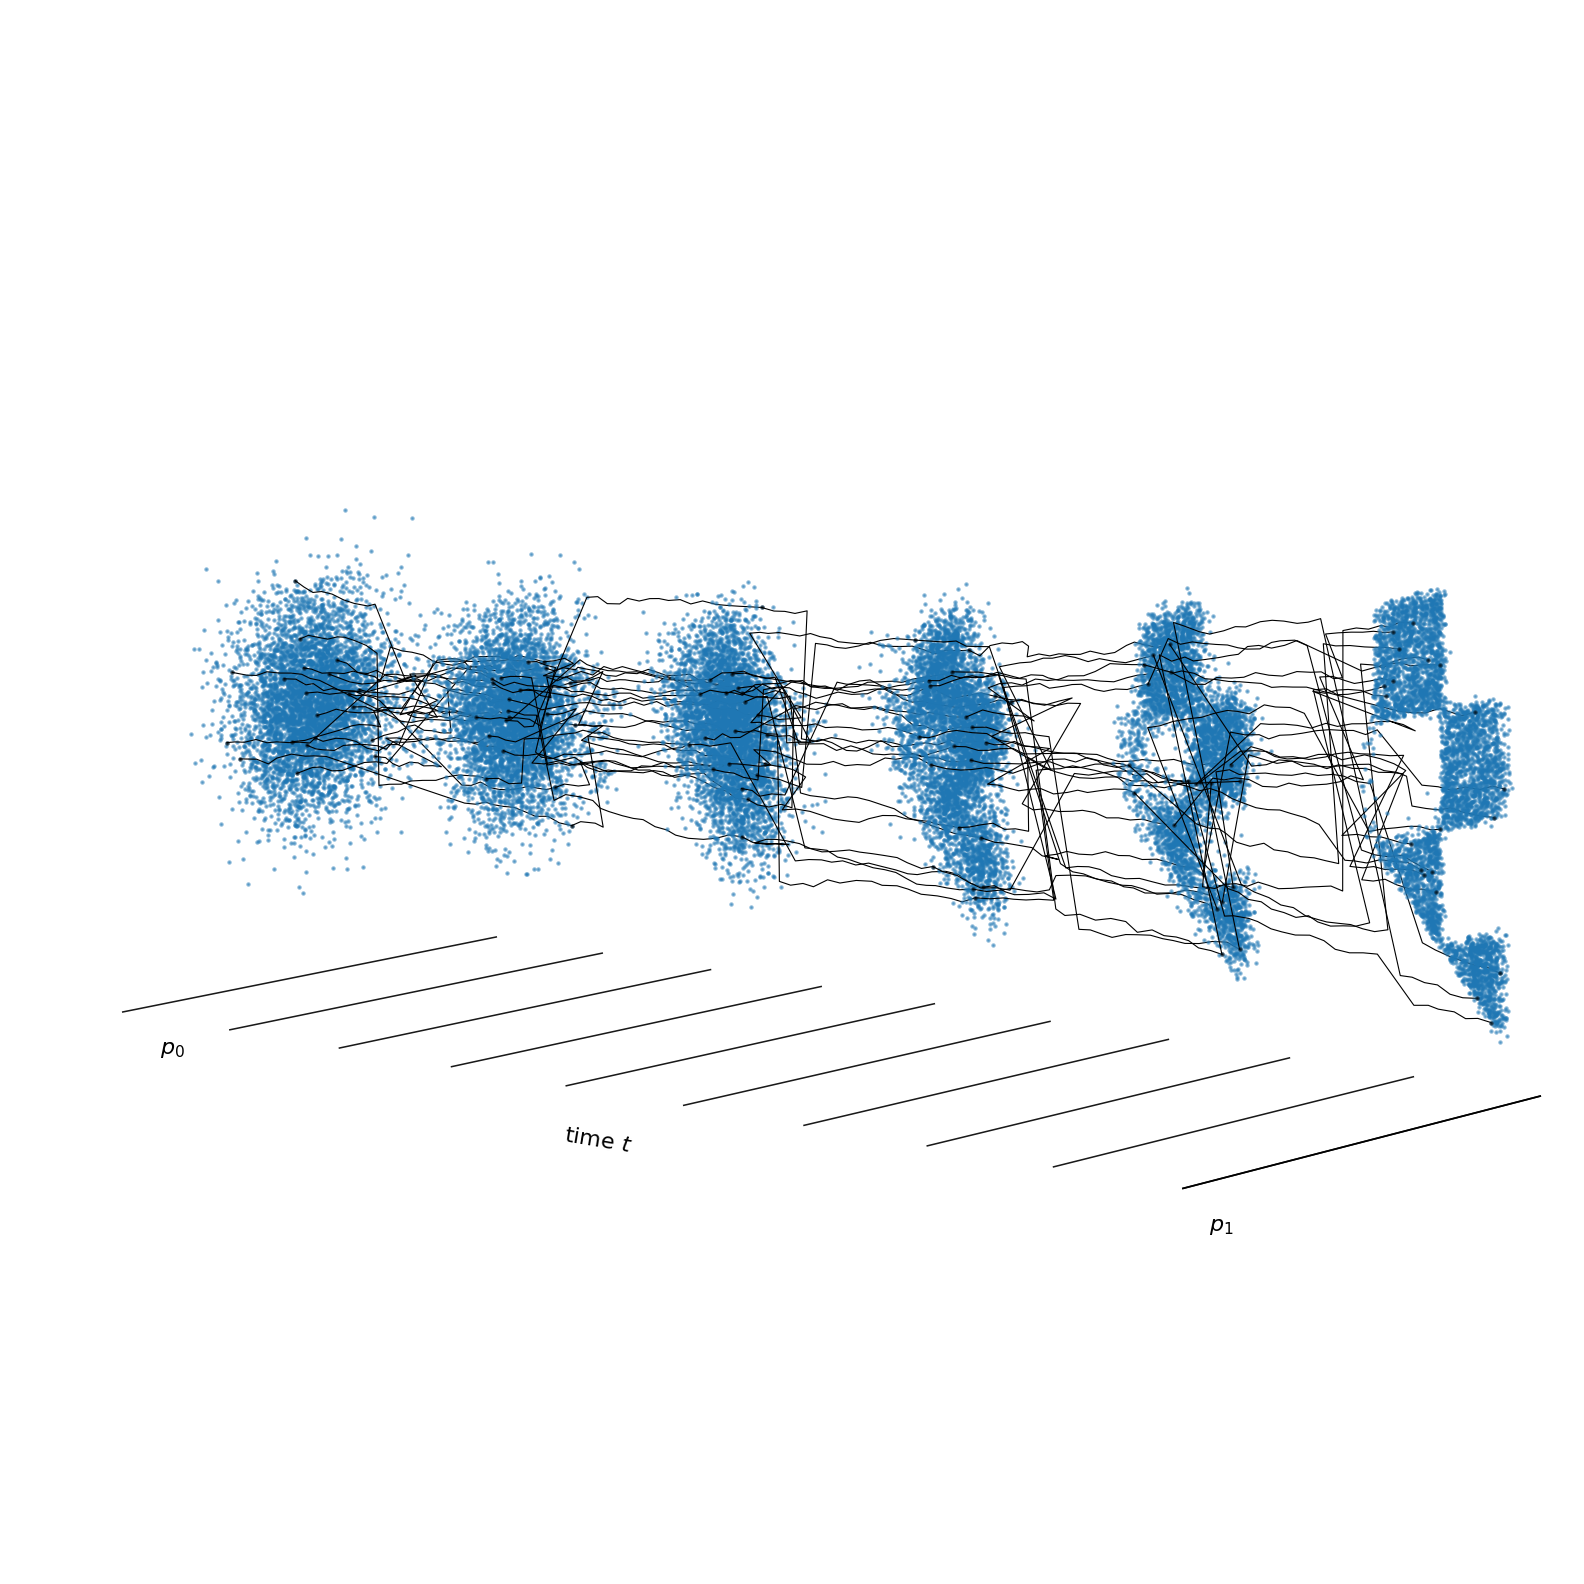

In [18]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name="different_alphas_adaptive_gammas", deg=-50)

Models loaded.


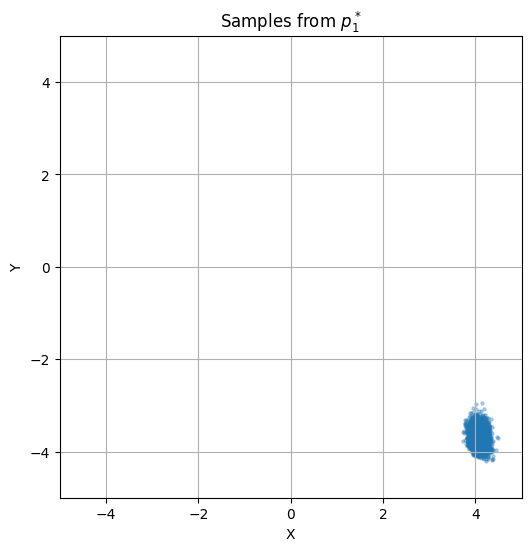

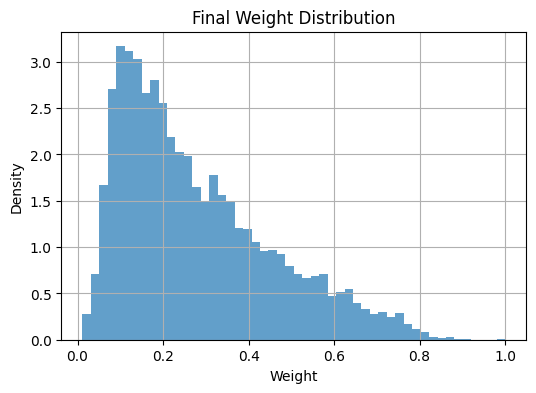

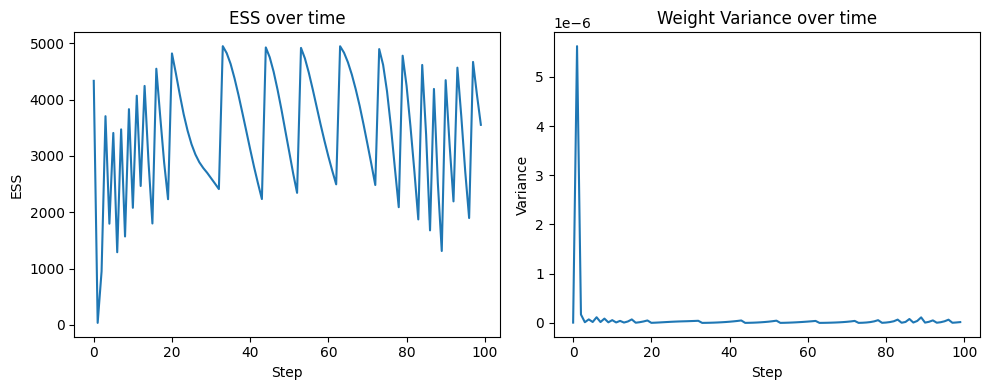

In [20]:
bs = 5000
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{experiment_id}/u_model1_X_given_A_default_alpha.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{experiment_id}/s_model1_X_given_A_default_alpha.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{experiment_id}/u_model2_XY_given_B_default_alpha.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{experiment_id}/s_model2_XY_given_B_default_alpha.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{experiment_id}/u_model3_X_different_alpha_t.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{experiment_id}/s_model3_X_different_alpha_t.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
# def s1_fn(x, t, A): return (v1_fn(x, t, A) * t - x) / (1 - t + 1e-8)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
# def s2_fn(x, t): return (v2_fn(x, t) * t - x) / (1 - t + 1e-8)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
# def s3_fn(z, t, B): return (v3_fn(z, t, B) * t - z) / (1 - t + 1e-8)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")


gamma_1 = lambda t: torch.ones_like(t)
gamma_2 = lambda t: -torch.ones_like(t)
gamma_3 = lambda t: torch.ones_like(t)
d_gamma_1 = lambda t: torch.zeros_like(t)
d_gamma_2 = lambda t: torch.zeros_like(t)
d_gamma_3 = lambda t: torch.zeros_like(t)



x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[gamma_1, gamma_2, gamma_3],
    d_gamma_list=[d_gamma_1, d_gamma_2, d_gamma_3],
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star = lambda z, t: v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + 
    # v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.5,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/different_alphas_constant_gammas")

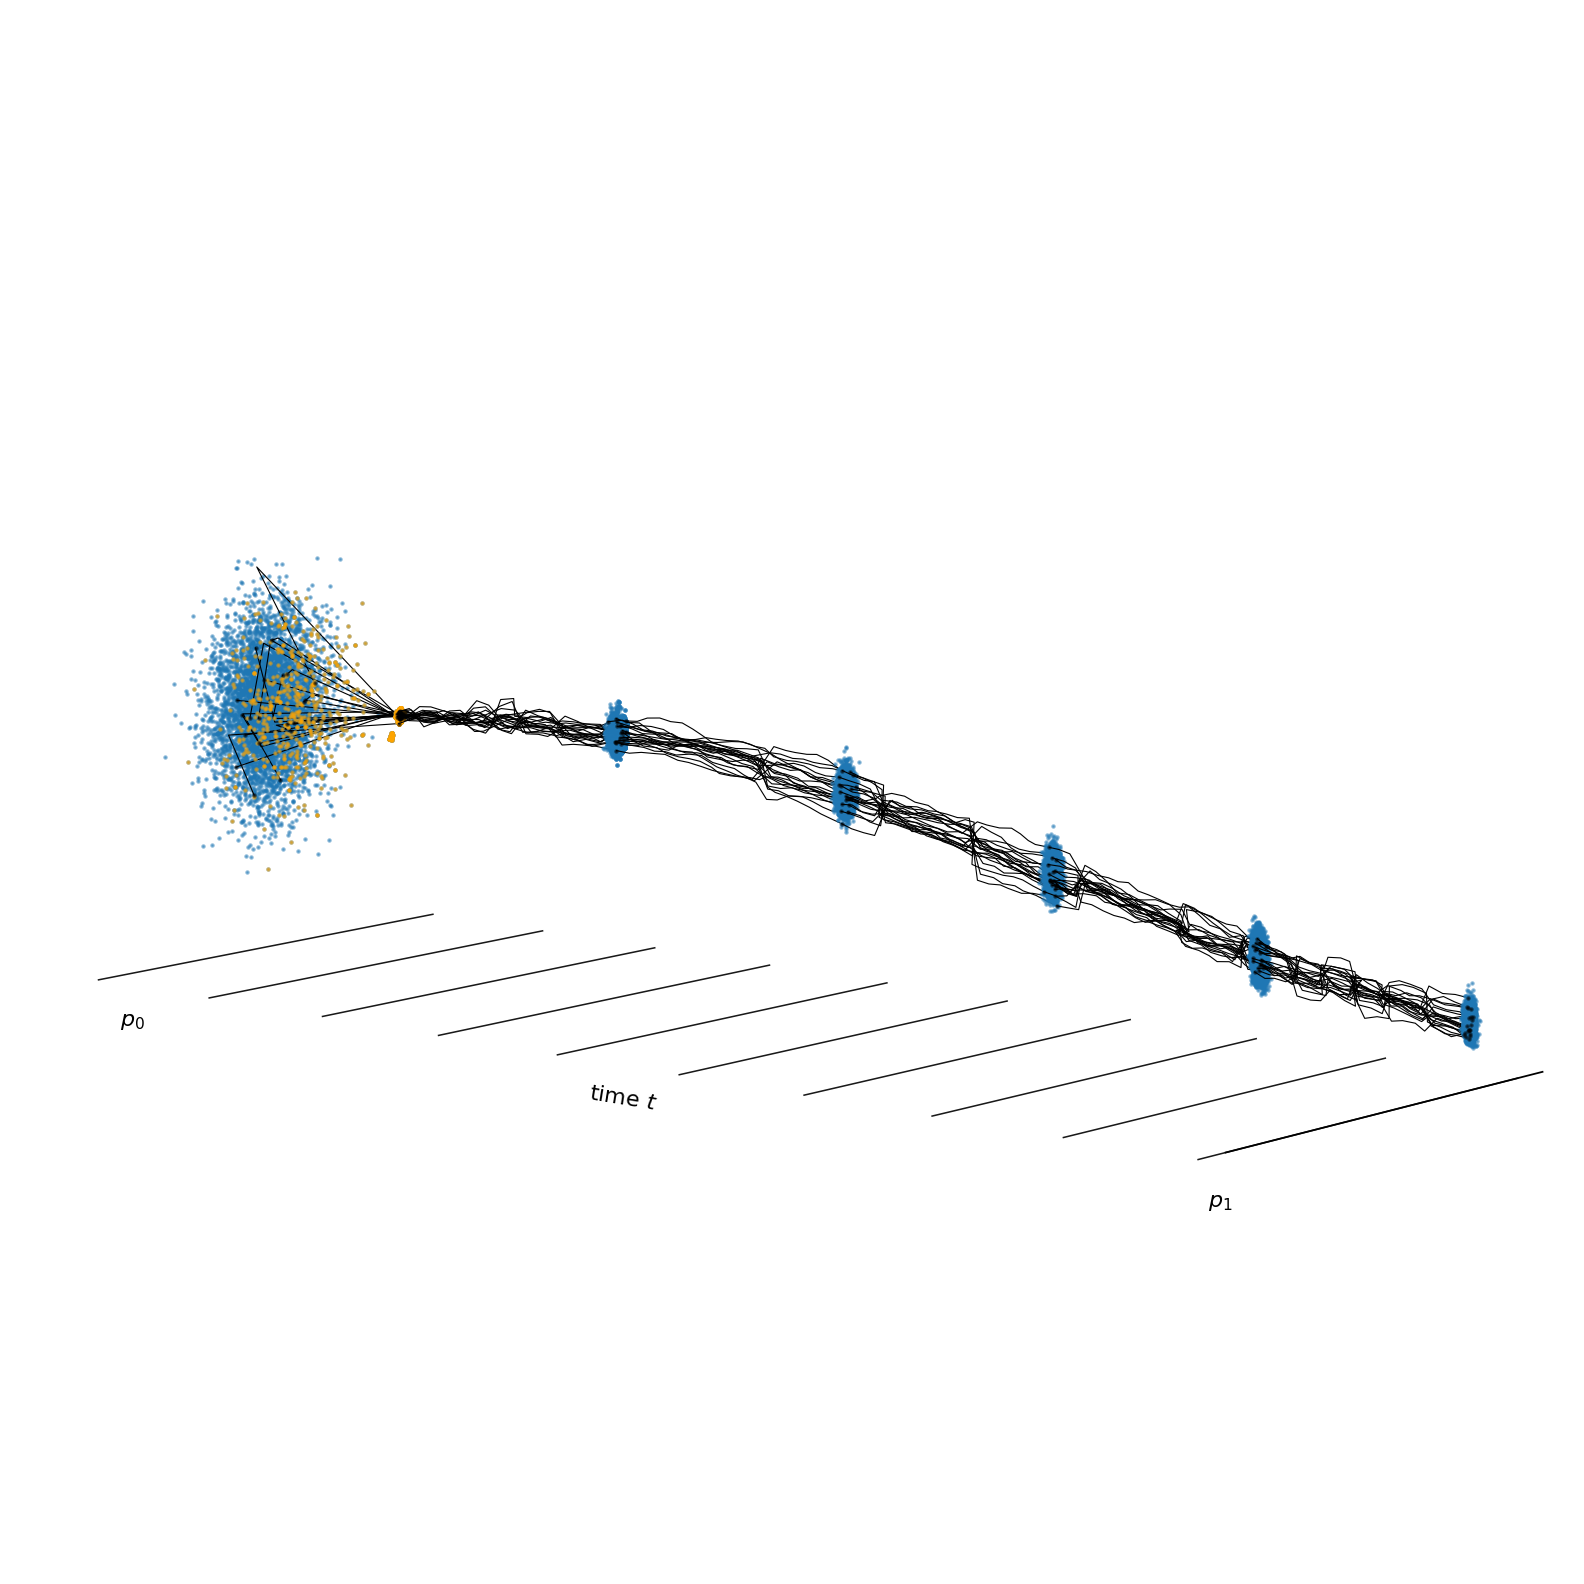

In [21]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=resample_history, experiment_id=experiment_id, name="failed_sample_path", deg=-50)

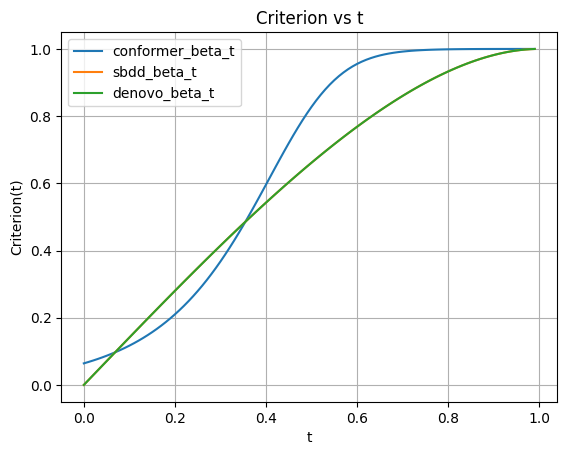

In [35]:
# SBDD와 Denovo : beta_t  = \sqrt{1 - (1 - t)^2}
# Conformer: beta_t = \sqrt{(1 - \exp\left(
#   -\left(
#     \tfrac{\mathcal{A}_{\text{end}} - \mathcal{A}_{\text{start}}}{12}
#     \cdot \operatorname{softplus}\!\big( (t - 0.5) \cdot 12 \big)
#     + \mathcal{A}_{\text{start}} \cdot t
#   \right)
# \right)}

#alpha_t = sqrt( 1 - exp ( - PI / T * tan (PI / 2 * t)))
# alpha_t = lambda t: torch.sqrt(1 - torch.exp(- (3.141592653589793 / 1000 * torch.tan(3.141592653589793 / 2 * t))))

# conformer_beta_t_squared = lambda t: (1 - torch.exp(-((A_end - A_start)/12 * torch.nn.functional.softplus((t - 0.5) * 12) + A_start * t)))
# sbdd_beta_t_squared = lambda t: (1 - (1 - t**2)**2)
# denovo_beta_t_squared = lambda t: (1 - (1 - t**2)**2)

# Criterion = lambda t: 1/conformer_beta_t_squared(t) + 1/sbdd_beta_t_squared(t) - 1/denovo_beta_t_squared(t)
# gamma_3 = lambda t : torch.tensor(-1 * (1-2*t)**2)

A_end = 20
A_start = 0.001

conformer_beta_t = lambda t: torch.sqrt(1 - torch.exp(-((A_end - A_start)/12 * torch.nn.functional.softplus((t - 0.5) * 12) + A_start * t)))
sbdd_beta_t = lambda t: torch.sqrt(1 - (1 - t**2)**2)
denovo_beta_t = lambda t: torch.sqrt(1 - (1 - t**2)**2)

alpha_1 = conformer_beta_t
alpha_2 = sbdd_beta_t
alpha_3 = denovo_beta_t
gamma_1 = lambda t : torch.tensor(1)
gamma_2 = lambda t : torch.tensor(1)
gamma_3 = lambda t : torch.tensor(-1.01)

alpha_list = [alpha_1, alpha_2, alpha_3]
gamma_list = [gamma_1, gamma_2, gamma_3]

Criterion = lambda t: sum([ gamma_list[i](t) / (alpha_list[i](t))**2 for i in range(len(alpha_list)) ])

# t = 0.001
# print(f"Criterion({t}) = ", Criterion(torch.tensor(t)).item())


# plot Criterion for t in [0.0:0.01:0.99]
t = torch.linspace(0.00000000001, 0.99, 100)
# plt.plot(t.numpy(), Criterion(t).numpy())
plt.plot(t.numpy(), conformer_beta_t(t).numpy(), label='conformer_beta_t')
plt.plot(t.numpy(), sbdd_beta_t(t).numpy(), label='sbdd_beta_t')
plt.plot(t.numpy(), denovo_beta_t(t).numpy(), label='denovo_beta_t')
plt.legend()
# plt.yscale('log')
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "Criterion_plot.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1): 
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

/tmp/ipykernel_45476/4293209157.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


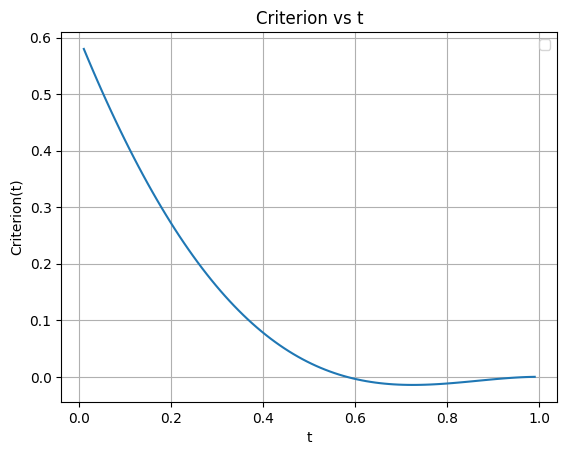

Criterion = 0 at t = 0.5742424130439758


In [57]:

A_end = 20
A_start = 0.001

conformer_beta_t_squared = lambda t: (1 - t**2)**2
sbdd_beta_t_squared = lambda t: (1- t)**2
denovo_beta_t_squared = lambda t: (1 -t)**2

Criterion = lambda t: denovo_beta_t_squared(t) - 0.4 * conformer_beta_t_squared(t) 


# plot Criterion for t in [0.0:0.01:0.99]
t = torch.linspace(0.01, 0.99, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
# plt.yscale('log')
# plt.plot(t.numpy(), conformer_beta_t_squared(t).numpy(), label='conformer_beta_t')
# plt.plot(t.numpy(), sbdd_beta_t_squared(t).numpy(), label='sbdd_beta_t')
# plt.plot(t.numpy(), denovo_beta_t_squared(t).numpy(), label='denovo_beta_t')
plt.legend()
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "Criterion_plot.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1): 
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

In [ ]:

# Make a dictionary that I can save and load as json file that includes alpha_t, beta_t, d_alpha_t, d_beta_t as self-contained lambda functions and the names of each scheduling for all the interpolants below:

default_interpolant = Interpolant(
    alpha_t = lambda t: torch.tensor(1-t),
    beta_t = lambda t: torch.tensor(t),
    d_alpha_t = lambda t : -1,
    d_beta_t = lambda t : 1
)


custom_interpolant_cos_t = Interpolant(
    alpha_t=lambda t: torch.cos(torch.pi * 0.5 * t),
    beta_t=lambda t: torch.sin(torch.pi * 0.5 * t),
    d_alpha_t=lambda t: - torch.pi * 0.5 * torch.sin(torch.pi * 0.5 * t),
    d_beta_t=lambda t: torch.pi * 0.5 * torch.cos(torch.pi * 0.5 * t)
)


s = torch.tensor(0.008)
denom = torch.cos(s / (1 + s) * torch.pi / 2) ** 2
abar  = lambda t: (torch.cos((t + s) / (1 + s) * torch.pi / 2) ** 2) / denom
dabar = lambda t: -torch.sin((t + s) / (1 + s) * torch.pi / 2) * torch.cos((t + s) / (1 + s) * torch.pi / 2) * (torch.pi / (1 + s)) / denom
alpha   = lambda t: torch.sqrt(abar(t))
beta    = lambda t: torch.sqrt(1 - abar(t))
dalpha  = lambda t: 0.5 * dabar(t) / torch.sqrt(abar(t))
dbeta   = lambda t: -0.5 * dabar(t) / torch.sqrt(1 - abar(t))
custom_interpolant_cosine = Interpolant(
    alpha_t=lambda t: torch.sqrt(abar(t)),
    beta_t=lambda t: torch.sqrt(1 - abar(t)),
    d_alpha_t=lambda t: 0.5 * dabar(t) / (torch.sqrt(abar(t)) + 1e-8),
    d_beta_t=lambda t: -0.5 * dabar(t) / (torch.sqrt(1 - abar(t))+ 1e-8)
)

beta0, beta1 = torch.tensor(0.1), torch.tensor(20.0)
I   = lambda t: beta0 * t + 0.5 * (beta1 - beta0) * t**2
dI  = lambda t: beta0 + (beta1 - beta0) * t
alpha   = lambda t: torch.sqrt(torch.exp(-0.5 * I(t)))
beta    = lambda t: torch.sqrt(1 - torch.exp(-0.5 * I(t)))
dalpha  = lambda t: -0.25 * dI(t) * torch.exp(-0.5 * I(t)) / torch.sqrt(torch.exp(-0.5 * I(t)))
dbeta   = lambda t: 0.25 * dI(t) * torch.exp(-0.5 * I(t)) / torch.sqrt(1 - torch.exp(-0.5 * I(t)))
custom_interpolant_ddpm_linear = Interpolant(
    alpha_t=lambda t: torch.sqrt(torch.exp(-0.5 * I(t))),
    beta_t=lambda t: torch.sqrt(1 - torch.exp(-0.5 * I(t))),
    d_alpha_t=lambda t: -0.25 * dI(t) * torch.exp(-0.5 * I(t)) / (torch.sqrt(torch.exp(-0.5 * I(t))) + 1e-8),
    d_beta_t=lambda t: 0.25 * dI(t) * torch.exp(-0.5 * I(t)) / (torch.sqrt(1 - torch.exp(-0.5 * I(t))) + 1e-8),
)



custom_interpolant_one_minus_t_squared = Interpolant(
    alpha_t=lambda t: (1 - t**2),
    beta_t=lambda t: t,
    d_alpha_t=lambda t: - 2*t,
    d_beta_t=lambda t: torch.ones_like(t)
)


custom_interpolant_denovo = Interpolant(
    alpha_t=lambda t: (1-t**2),
    beta_t=lambda t: torch.sqrt((1 - (1-t**2)**2)),
    d_alpha_t=lambda t: -2*t,
    d_beta_t=lambda t: (2*t*(1 - t**2)) / torch.sqrt(2*t**2 - t**4 + 1e-8),
)




sigmoid_t = lambda t: torch.sqrt(1 - torch.exp(-((20)/12 * torch.nn.functional.softplus((t - 0.5) * 12) + 0.001 * t)))
dsigmoid_t = lambda t: (torch.exp(-((20/12)*torch.nn.functional.softplus((t-0.5)*12) + 0.001*t)) * (20*torch.sigmoid((t-0.5)*12) + 0.001)) / (2*torch.sqrt(1 - torch.exp(-((20/12)*torch.nn.functional.softplus((t-0.5)*12) + 0.001*t)) + 1e-12))

custom_interpolant_sigmoid = Interpolant(
    alpha_t=lambda t: sigmoid_t(1-t),
    beta_t=lambda t: t,
    d_alpha_t=lambda t: -dsigmoid_t(1-t),
    d_beta_t=lambda t: torch.ones_like(t)
)


# 1 - t, 1 - t**2, sigmoid / 수치적으로 안정적인 scheduling / 자동 스크립트 / Seed 3개 평균,std
# GMM - 시간 되면.